In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import copy
import logging

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler()
    ]
)

%reload_ext autoreload
%autoreload 2

from config.constants import Constants
from config.train_config import load_train_config
from core_data_prep.core_data_prep import DataPreparer
from core_inference.allocators.signal_predictor_allocator import SignalPredictorAllocator
from core_inference.streaming_validation import run_streaming_validation
from data.processed.data_processing_utils import print_data_statistics
from data.processed.dataset_pytorch import DatasetPytorch
from modeling.allocator_evaluation import find_best_allocator_params, test_cum_wealth
from modeling.modeling_utils import load_model_and_allocator_params, print_model_parameters
from modeling.rl.visualization.position_plot import plot_position_heatmap
from modeling.rl.visualization.wealth_plot import plot_cumulative_wealth
from modeling.trainer import Trainer

config = load_train_config()
torch.backends.cudnn.benchmark = config.train_config.cudnn_benchmark

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"Config:\n {config}")


Using device: cpu
Config:
 ExperimentConfig(data_config=DataConfig(retriever=<data.raw.retrievers.alpaca_markets_retriever.AlpacaMarketsRetriever object at 0x14b2bf020>, symbol_or_symbols=['AAPL', 'ACWI', 'AMD', 'AMZN', 'APLD', 'ARKK', 'AVGO', 'B', 'BAC', 'BKNG', 'BMY', 'BSX', 'CIFR', 'CSCO', 'DIA', 'DVN', 'EEM', 'EFA', 'EMXC', 'EWT', 'EWY', 'FBTC', 'FCX', 'GDX', 'GLD', 'GOOG', 'GOOGL', 'HOOD', 'IBIT', 'IEMG', 'IGV', 'IJR', 'INTC', 'IONQ', 'IREN', 'IVV', 'IVW', 'IWF', 'IWM', 'IYR', 'KO', 'KRE', 'MARA', 'META', 'MRVL', 'MSFT', 'MSTR', 'MU', 'NEE', 'NFLX', 'NKE', 'NOW', 'NVDA', 'ORCL', 'OXY', 'PLTR', 'PYPL', 'QBTS', 'QLD', 'QQQ', 'QQQM', 'RGTI', 'RIOT', 'RKLB', 'RSP', 'SHEL', 'SLB', 'SLV', 'SMCI', 'SMH', 'SOXX', 'SPXL', 'SPY', 'SPYG', 'STM', 'TFC', 'TQQQ', 'TSLA', 'TSM', 'UBER', 'UPRO', 'USB', 'VNQ', 'VOO', 'VT', 'VTI', 'VTWO', 'VUG', 'WFC', 'WMT', 'WULF', 'XBI', 'XLC', 'XLE', 'XLI', 'XLK', 'XLP', 'XLV', 'XLY', 'XOM'], frequency=<alpaca.data.timeframe.TimeFrame object at 0x14b2f3260>, st

In [2]:
retriever = config.data_config.retriever
retrieval_result = retriever.bars_with_quotes(
    symbol_or_symbols=config.data_config.symbol_or_symbols,
    start=config.data_config.start,
    end=config.data_config.end,
)

2026-08-10 10:46:28,422 - INFO - Downloading cached Alpaca bars with quotes from cloud storage: bars_with_quotes/1Min_2026-01-01-2026-02-01_AAPL+ACWI+AMD+AMZN+APLD+AVGO+BAC+BITB+BITU+BMY+BOIL+C+CIFR+CLSK+CSCO+DIA+DKNG+ETHA+EWY+FBTC+GBTC+GDX.pkl
/Users/ivan.kurnosau/Projects/intraday-portfolio-management/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_preparer = DataPreparer(
    normalizer=config.data_config.normalizer,
    missing_values_handler=config.data_config.missing_values_handler_polars,
    in_seq_len=config.data_config.in_seq_len,
    frequency=str(config.data_config.frequency),
    validator=config.data_config.validator
)

(X_train, y_train, statistics_train), (X_val, y_val, statistics_val), (X_test, y_test, statistics_test) = \
    data_preparer.get_experiment_data(
        data=retrieval_result,
        start_date=config.data_config.start,
        end_date=config.data_config.end,
        features=config.data_config.features_polars,
        statistics=config.data_config.statistics,
        target=config.data_config.target,
        train_set_last_date=config.data_config.train_set_last_date,
        val_set_last_date=config.data_config.val_set_last_date,
        backend='loky'
    )

X_train.shape, y_train.shape, statistics_train['next_return'].shape, \
    X_val.shape, y_val.shape, statistics_val['next_return'].shape, \
    X_test.shape, y_test.shape, statistics_test['next_return'].shape

2026-08-04 11:25:45,463 - INFO - Skipping day 2024-11-02 00:00:00-04:00 because it has less than 100 assets
2026-08-04 11:32:33,181 - INFO - Found 303 daily slices
2026-08-04 11:32:33,243 - INFO - Trained per-asset targets


((92667, 100, 60, 16),
 (92667, 100),
 (92667, 100),
 (8993, 100, 60, 16),
 (8993, 100),
 (8993, 100),
 (16813, 100, 60, 16),
 (16813, 100),
 (16813, 100))

In [ ]:
next_return_train, spread_train, volatility_train, \
    next_return_val, spread_val, volatility_val, \
    next_return_test, spread_test, volatility_test = \
        statistics_train['next_return'], statistics_train['spread'], statistics_train['volatility'], \
        statistics_val['next_return'], statistics_val['spread'], statistics_val['volatility'], \
        statistics_test['next_return'], statistics_test['spread'], statistics_test['volatility']

print_data_statistics(statistics_train, statistics_val, statistics_test)

In [ ]:
model = config.model_config.model
print(model)
print_model_parameters(model)

TemporalSpatial(
  (asset_embed): Embedding(100, 16)
  (asset_proj): Linear(in_features=16, out_features=256, bias=False)
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (spatial_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [ ]:
train_loader = DatasetPytorch(X_train, y_train, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=config.train_config.shuffle,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=config.train_config.drop_last
)
val_loader = DatasetPytorch(X_val, y_val, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=False,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=config.train_config.drop_last
)

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=config.train_config.loss_fn,
    optimizer=config.train_config.optimizer,
    scheduler=config.train_config.scheduler,
    num_epochs=config.train_config.num_epochs,
    early_stopping_patience=config.train_config.early_stopping_patience,
    device=config.train_config.device,
    metrics=config.train_config.metrics,
    save_path=config.train_config.save_path
)

model, history = trainer.train()

2026-08-04 11:36:23,098 - INFO - Model compiled with torch.compile()


In [ ]:
load_model=False

if load_model:
    model, allocator_params = load_model_and_allocator_params(
        model_path="signal_predictor_with_allocator_params.pth",
        device=device,
        config=config
    )

else: 
    best_select_from_n_best, best_confidence_threshold = find_best_allocator_params(
        signal_predictor=model,
        loader=val_loader,
        next_returns=next_return_val,
        spreads=spread_val,
        volatilities=volatility_val,
        trade_asset_count=config.rl_config.trade_asset_count,
        fee=config.rl_config.fee,
        spread_multiplier=config.rl_config.spread_multiplier,
        device=device,
        allow_short_positions=config.rl_config.allow_short_positions,
        n_runs_per_param=20,
    )
    allocator_params = {
        "trade_asset_count": config.rl_config.trade_asset_count,
        "select_from_n_best": best_select_from_n_best,
        "confidence_threshold": best_confidence_threshold,
    }
    allocator_params["select_from_n_best"], allocator_params["confidence_threshold"]

In [ ]:
use_dummy_allocator = False

if use_dummy_allocator:
    from core_inference.allocators.deterministic_one_stock_allocator import (
        DeterministicOneStockAllocator,
    )

    allocator = DeterministicOneStockAllocator(
        n_assets=len(config.data_config.symbol_or_symbols),
    ).to(device)
    allocator.reset_counter()
else:
    allocator = SignalPredictorAllocator(
        signal_predictor=model,
        trade_asset_count=allocator_params["trade_asset_count"],
        select_from_n_best=allocator_params["select_from_n_best"],
        confidence_threshold=allocator_params["confidence_threshold"],
        allow_short_positions=config.rl_config.allow_short_positions,
    ).to(device)

test_loader = DatasetPytorch(X_test, y_test, learning_task='regression').as_dataloader(
    batch_size=config.train_config.batch_size,
    shuffle=False,
    num_workers=config.train_config.num_workers,
    prefetch_factor=config.train_config.prefetch_factor,
    pin_memory=config.train_config.pin_memory,
    persistent_workers=config.train_config.persistent_workers,
    drop_last=False
)

cum_wealth, realized_returns, allocations, confidences = test_cum_wealth(
    allocator,
    test_loader,
    next_return_test,
    spread_test,
    volatility_test,
    fee=config.rl_config.fee,
    spread_multiplier=config.rl_config.spread_multiplier,
    device=device,
)
cum_wealth

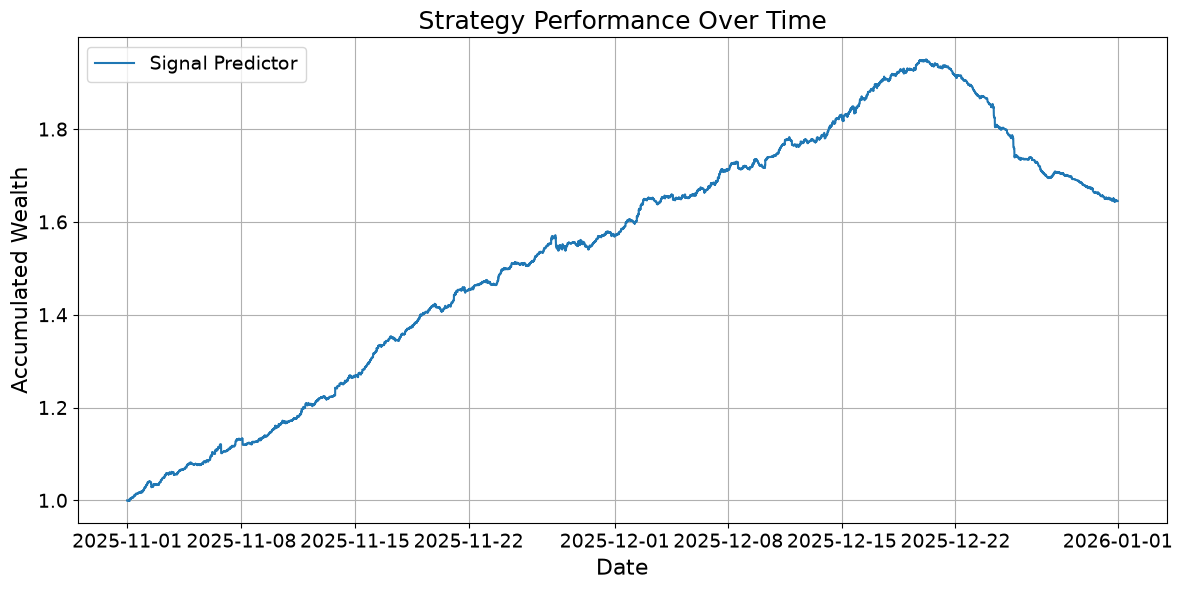

In [26]:
returns_dict = plot_cumulative_wealth(
    returns_dict={
        'Signal Predictor': list(realized_returns) 
    }, 
    start_time=config.data_config.val_set_last_date, 
    end_time=config.data_config.end,
    ours_to_include=[],
    baseline_to_include=[],
    year_start=9
)

In [ ]:
plot_position_heatmap(allocations[:100], asset_names=sorted(list(retrieval_result.keys())))

In [27]:
state_dict = (
    model.module.state_dict()
        if isinstance(model, torch.nn.DataParallel)
    else model.state_dict()
)

torch.save(
    {
        "model_state_dict": copy.deepcopy(state_dict),
        "allocator_params": {
            "trade_asset_count": config.rl_config.trade_asset_count,
            "select_from_n_best": int(best_select_from_n_best),
            "confidence_threshold": float(best_confidence_threshold),
        },
    },
    "signal_predictor_with_allocator_params.pth",
)

In [ ]:
daily_slices = data_preparer._get_daily_slices(
    retrieval_result,
    start_date=config.data_config.val_set_last_date,
    end_date=config.data_config.end,
    slice_length=Constants.Data.TRADING_DAY_LENGTH_MINUTES + config.data_config.in_seq_len + config.data_config.normalizer.get_window() + 30,
    verbose=True
)

# assert all the slices have the same length
assert len(set([len(cur_day_asset_slice) for cur_day_slices in daily_slices for cur_day_asset_slice in cur_day_slices.values()])) == 1

len(daily_slices), len(daily_slices[0]), len(daily_slices[0]['AAPL'])

2026-08-04 11:58:16,156 - INFO - Last timestamp counts across all slices and stocks:
2026-08-04 11:58:16,158 - INFO -   2025-11-03 16:00:00-05:00: 100 occurrences
2026-08-04 11:58:16,159 - INFO -   2025-11-04 15:59:00-05:00: 1 occurrences
2026-08-04 11:58:16,159 - INFO -   2025-11-04 16:00:00-05:00: 99 occurrences
2026-08-04 11:58:16,160 - INFO -   2025-11-05 15:59:00-05:00: 3 occurrences
2026-08-04 11:58:16,161 - INFO -   2025-11-05 16:00:00-05:00: 97 occurrences
2026-08-04 11:58:16,161 - INFO -   2025-11-06 15:59:00-05:00: 4 occurrences
2026-08-04 11:58:16,162 - INFO -   2025-11-06 16:00:00-05:00: 96 occurrences
2026-08-04 11:58:16,162 - INFO -   2025-11-07 16:00:00-05:00: 100 occurrences
2026-08-04 11:58:16,162 - INFO -   2025-11-10 15:59:00-05:00: 2 occurrences
2026-08-04 11:58:16,163 - INFO -   2025-11-10 16:00:00-05:00: 98 occurrences
2026-08-04 11:58:16,165 - INFO -   2025-11-11 15:59:00-05:00: 1 occurrences
2026-08-04 11:58:16,165 - INFO -   2025-11-11 16:00:00-05:00: 99 occurr

In [ ]:
cur_cash = run_streaming_validation(
    config=config,
    data_preparer=data_preparer,
    allocator=allocator,
    daily_slices=daily_slices,
    x_test=X_test,
    allocations=allocations,
    realized_returns=realized_returns,
    next_returns=next_return_test,
    validate_inputs=True,
    validate_returns=True,
    initial_cash=1e10,
    order_size_notional=1e9,
    reset_allocator=use_dummy_allocator,
    n_days=2,
)
cur_cash